In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# **Soal 1**

In [2]:
x1 = [15, 7, 9, 11, 13, 12, 9, 11, 12, 11]
x2 = [7, 3, 2, 4, 6, 5, 3, 3, 4, 3]
y = [5, 2, 3, 4, 5, 3, 3, 3, 4, 3]

**Keterangan:**
- x1 := pendapatan keluarga (juta Rp)
- x2 := jumlah anggota keluarga
- y := pengeluaran keluarga (juta Rp)

In [3]:
df = pd.DataFrame({'x1': x1, 'x2': x2, 'y': y})
df

,x1,x2,y
0,15,7,5
1,7,3,2
2,9,2,3
3,11,4,4
4,13,6,5
5,12,5,3
6,9,3,3
7,11,3,3
8,12,4,4
9,11,3,3


**Pertanyaannya:**

Gunakan metode regresi linear multiple untuk menentukan model forecasting. Lalu gunakan model tersebut untuk memprediksi, jika x1 = 10 dan x2 = 4, maka y = ... ?

Eh. Btw kepo sama grafik datanya. Coba cek dulu.

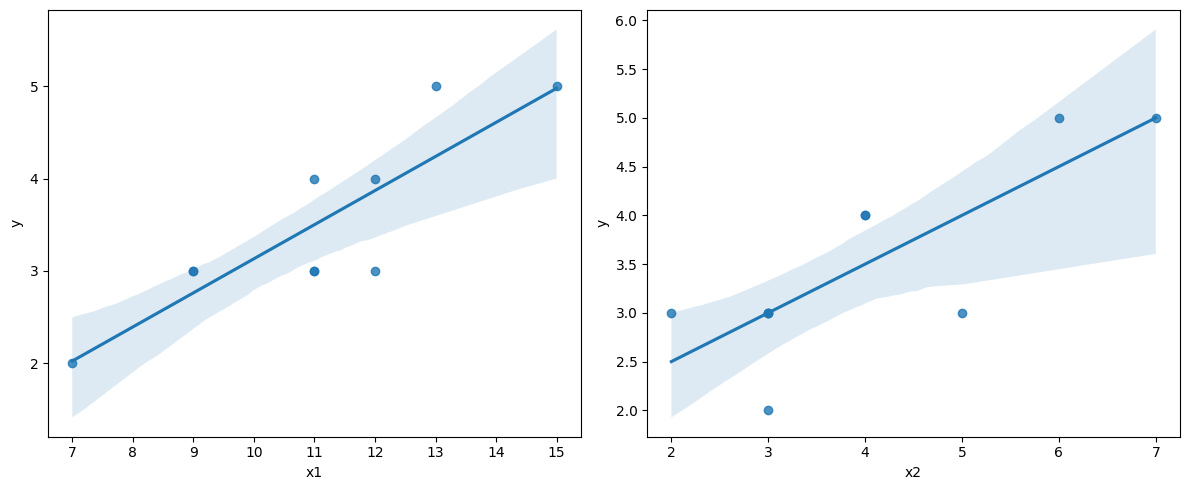

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.regplot(data=df, x="x1", y="y", ax=ax[0])
sns.regplot(data=df, x="x2", y="y", ax=ax[1])

plt.tight_layout()
plt.show()

2 2 nya, baik x1 maupun x2, sama-sama punya hubungan linear yang positif terhadap y. Dan Jarak titik-titik terhadap garis ga terlalu jauh secara signifikan. Jadi, wajar di soal mintanya pakai regresi linear. 

In [5]:
X = df[['x1', 'x2']]
y = df['y']

In [6]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [7]:
print("Konstanta :", model.intercept_)
print("Koefisien :", model.coef_)

Konstanta : -0.15724381625441852
Koefisien : [0.27208481 0.16607774]


Jadi model forecasting metode regresi linear multiple yang sesuai dengan data adalah: 

y = -0.15724381625441852 + (0.27208481) x1 + (0.16607774) x2

In [8]:
model.predict([[10, 4]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.22791519])

Dengan menggunakan model forecasting tersebut, pengeluaran keluarga dengan 4 anggota dan pendapatan Rp10.000.000 diprediksi sebesar Rp3.227.915. 

In [9]:
%reset -f

# **Soal 5**

In [12]:
tahun = np.array([2015, 2016, 2017, 2018]).reshape(-1, 1)
penjualan = np.array([3900, 4000, 4250, 4800])

**Pertanyaannya:**

Berapa prediksi penjualan pada tahun 2019 jika model yang digunakan dibangun menggunakan metode trend linear? Informasi tambahan: B_alpha = 200, S_alpha = 3900, serta alpha dan beta masing-masing diambil 10%. 

In [13]:
model = LinearRegression()
model.fit(tahun, penjualan)

LinearRegression()

In [14]:
model.predict([[2019]])

array([4975.])

Prediksi penjualan tahun 2019 adalah 4975 unit.

**Thoughts:**

Informasi tambahan B_alpha, alpha, S_alpha, beta pada soal sifatnya lebih untuk mengecoh. Membangun model dengan metode trend linear ga perlu itu, sebab komponennya hanya y = ax + b.

In [15]:
%reset -f

# **Soal 6**

In [21]:
periode = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
harga = np.array([1950, 2000, 2010, 1985, 1990, 2000, 2020, 1980, 2040, 2140])

<Axes: >

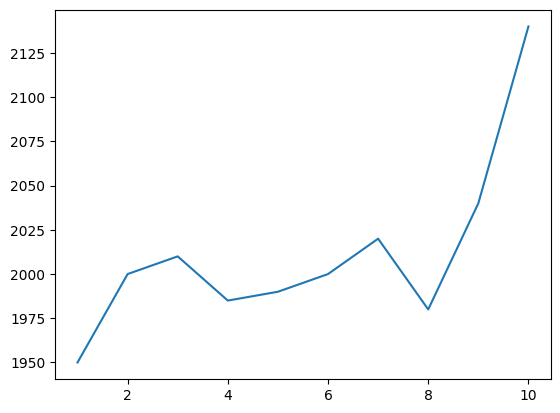

In [ ]:
sns.lineplot(x=periode, y=harga)

<Axes: >

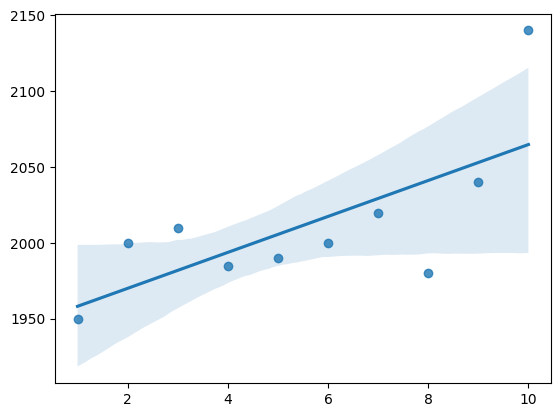

In [24]:
sns.regplot(x=periode, y=harga)

Trennya naik, walau, memang ada fluktuasi naik-turun. Pakai regresi polinomial mungkin cocok (?). Cobakan pakai loop buat cari degree teroptimal.

In [30]:
# ======
# MODEL
# ======
models = []
errors = []
for i in range(1, 5):
    model = make_pipeline(
        PolynomialFeatures(degree=i),
        LinearRegression()
    )

    model.fit(periode[int(0.2*len(periode)):].reshape(-1, 1), harga[int(0.2*len(harga)):])
    models.append(model)

    y_pred = model.predict(periode[:int(0.2*len(periode))].reshape(-1, 1))

    mse = mean_squared_error(harga[:int(0.2*len(harga))], y_pred)

    # print(f"Mean Squared Error: {mse}")

    errors.append(mse)

# ============
# BEST RESULT
# ============
best_model = models[errors.index(min(errors))]
print("Seluruh Error Model: ", errors)
print(f"Best Model Error: {min(errors)}")
print(f"Best Model Degree: {errors.index(min(errors)) + 1}")
y_inference = best_model.predict([[11]])
print(y_inference)

Seluruh Error Model:  [915.4567035147436, 12970.476367630334, 1034.2970521603343, 123590.73572104947]
Best Model Error: 915.4567035147436
Best Model Degree: 1
[2083.57142857]


Ternyata kalau pakai regresi linear, yang teroptimal tetap regresi linear biasa (degree 1), dengan hasil prediksi harga untuk periode 10 sebesar 2083. Tapi.. error nya gede-gede gitu ya o_o Emang wajar atau gimana? Btw ini MSE. 

Ada lagi yang namanya RMSE, akarnya dari MSE. Kalau RMSE, jadinya error nya sekitaran 30an, yang mana ga besar signifikan kalau dibanding dengan satuan harga yang sebenarnya (hanya sekitar 1-2%an). Jadi berdasarkan itu, dapat diterima sih seharusnya.